In [52]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi
#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os,sys
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

In [53]:
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams

In [54]:
path = os.path.join(os.getcwd(), 'Iris.csv')
df = pd.read_csv(path)



### Explained Sepal Length and Petal length in flower

#### What is a Sepal?

- Sepals are the outermost parts of a flower.
- They are typically green and leaf-like, forming a protective layer around the bud before it blooms.
- Collectively, sepals are called the calyx.

#### Sepal Length:

- This is the distance from the base to the tip of a sepal.
- It’s measured in centimeters (***cm***) in datasets like Iris.
- Sepal length can vary across species and is used to help identify or classify flowers

#### What is a Petal?

- Petals are the colorful, often fragrant parts of a flower that attract pollinators.
- They form the corolla, which sits inside the ring of sepals.

#### Petal Length

- This is the distance from the base to the tip of a petal.
- Also measured in centimeters (***cm***).
- Petal length is often more variable and distinctive across species than sepal length.

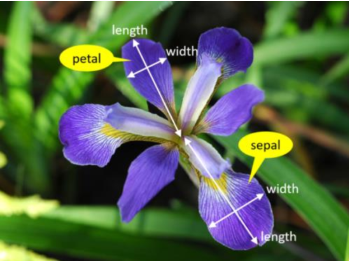

- Classify species (e.g., Setosa vs. Virginica)
- Visualize morphological differences
- Train machine learning models
- Setosa tends to have shorter petals and wider sepals
- Virginica has longer petals and narrower sepals


### Initial Inspections



In [55]:
df = df.drop(['Id'],axis=1)

In [56]:
print(df.columns.values)
print(df.info())
print(df.describe())

['SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm' 'Species']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%      

#### To check for duplicate rows


In [57]:
# Check for duplicate rows
duplicates = df[df.duplicated()]

# Summary
print(f"Total duplicate rows: {len(duplicates)}")
print("\nDuplicate rows:\n", duplicates)
print(f'Duplicate Index number: {duplicates.index.values}')


Total duplicate rows: 3

Duplicate rows:
      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
34             4.9           3.1            1.5           0.1     Iris-setosa
37             4.9           3.1            1.5           0.1     Iris-setosa
142            5.8           2.7            5.1           1.9  Iris-virginica
Duplicate Index number: [ 34  37 142]


### Check for missing value

In [58]:
# Check for missing value
print(df.isnull().sum())
# print(df[df['SepalLengthCm'].isnull() == True].index.values)
NullIndex = []
for clm in df.columns.values:
    NullIndex = df[df[clm].isnull() == True].index.values
    if len(NullIndex)!=0:
        print(f'Index numbers\n: {NullIndex}')
    else:
        print(f'not null present in regressosr variablr {clm}')

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
not null present in regressosr variablr SepalLengthCm
not null present in regressosr variablr SepalWidthCm
not null present in regressosr variablr PetalLengthCm
not null present in regressosr variablr PetalWidthCm
not null present in regressosr variablr Species


### Check if CategoricalDtype present

In [59]:
print(f'Data type:\n{df.dtypes}')
tableDispFormatt('Check categeriocal')
# Method 1: Check Data type categeriocal
#for col in df.columns:
#    if isinstance(df[col].dtype, pd.CategoricalDtype):
#        print(f"{col} is categorical")
        
# Method 2: Check Data type categeriocal
for col in df.select_dtypes(include='object'):
    tableDispFormatt(f'Regressor Variable: {col}')
    print(f"{df[col].value_counts()}")

Data type:
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object
=============================== Check categeriocal =========================================
=============================== Regressor Variable: Species ================================
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### Explore Numerical Variables

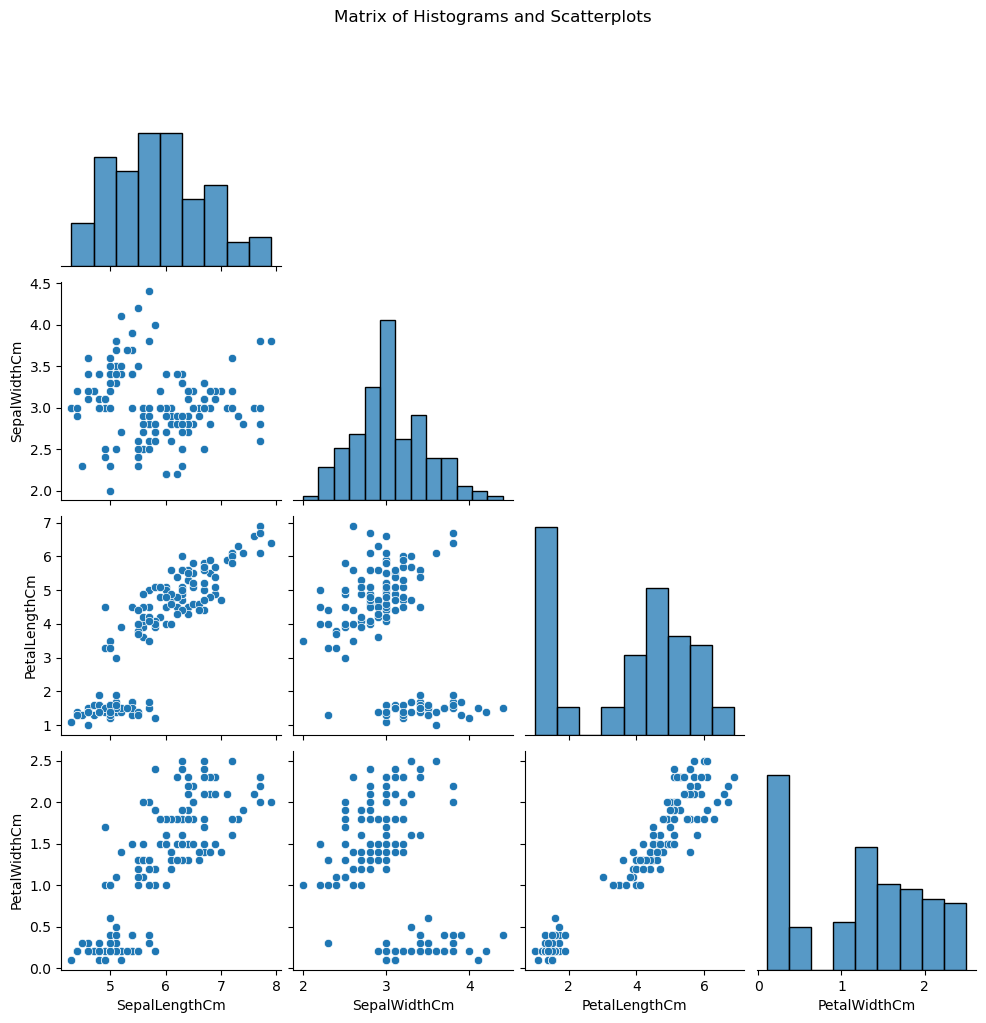

In [60]:
sns.pairplot(df, diag_kind='hist', corner=True,)
plt.suptitle("Matrix of Histograms and Scatterplots", y=1.02)
plt.show()


### check skewness and kurtosis of a dataset

**Skewness**: Measures asymmetry of the distribution.
- Positive skew → tail on the right
- Negative skew → tail on the left

**Kurtosis**: Measures tailedness or peakedness.
- High kurtosis → heavy tails (outliers)
- Low kurtosis → light tails (flat distribution)
- Normal distribution has kurtosis ≈ 3 (excess kurtosis ≈ 0)


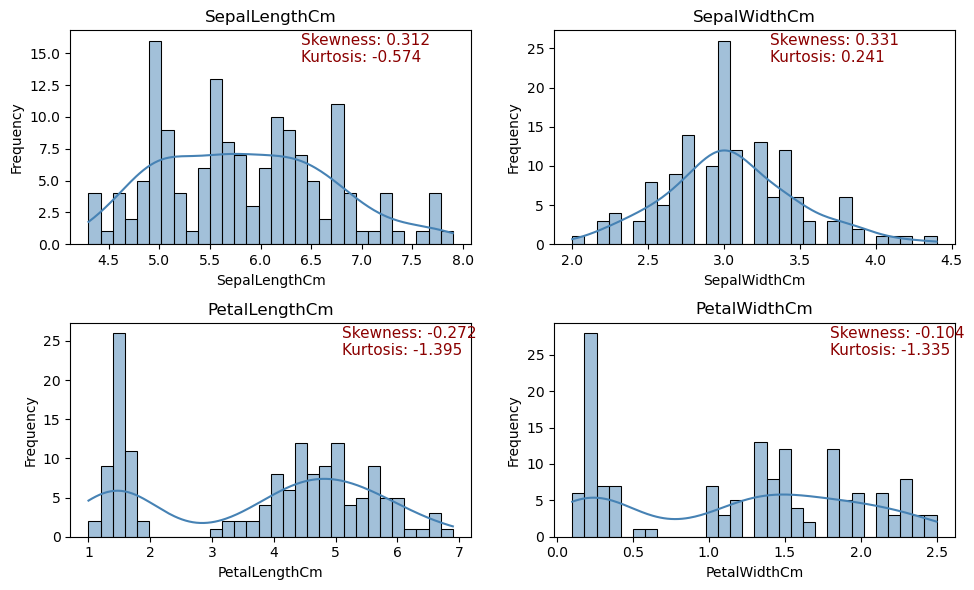

In [61]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axes = axes.flatten()
numeric_cols = df.select_dtypes(include='number').columns
# Plot each numeric column
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, ax=axes[i], bins=30, kde=True, color='steelblue')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    skew_val = skew(df[col])
    kurt_val = kurtosis(df[col])  # excess kurtosis
    # Annotate metrics
    annotation = f"Skewness: {skew_val:.3f}\nKurtosis: {kurt_val:.3f}"
    axes[i].text(
        x=df[col].quantile(0.75), 
        y=axes[i].get_ylim()[1]*0.85, 
        s=annotation, 
        fontsize=11, 
        color='darkred'
    )
    # Flag high skewness
    if abs(skew_val) > 1:
        axes[i].set_title(f"{col} (Highly Skewed)", color='crimson')
    else:
        axes[i].set_title(f"{col}")

    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()



In above diagram we can see sepal width and length are look like symmetry. Possible normalizations found in this two regressors. Letter Petal length and width far away from symmetry, Also we can’t say about the Skewness and Kurtosis.

Also you can notices Kurtosis of Sepal with is higher then rest regressor variables. It's look like some sharp peak then others. For rest regressor you can see Kurtosis are -ve.

#### Outliesr detections

#### Interquartile Range Definition:

The interquartile range defines the difference between the third and the first quartile. Quartiles are the partitioned values that divide the ***whole series into 4 equal parts***. So, **there are 3 quartiles**. 
- First Quartile is denoted by **Q1** known as the lower quartile 
- The second Quartile is denoted by **Q2** 
- Third Quartile is denoted by **Q3** known as the upper quartile. 

- Q1 – Lower Quartile Part
- Q2 – Median
- Q3 – Upper Quartile Part

Therefore, the interquartile range is equal to the upper quartile minus lower quartile.

#### Interquartile Range Formula:

The difference between the upper and lower quartile is known as the interquartile range. The formula for the interquartile range is given below

***Interquartile range = Upper Quartile – Lower Quartile = Q­3 – Q­1***

where Q1 is the first quartile and Q3 is the third quartile of the series.

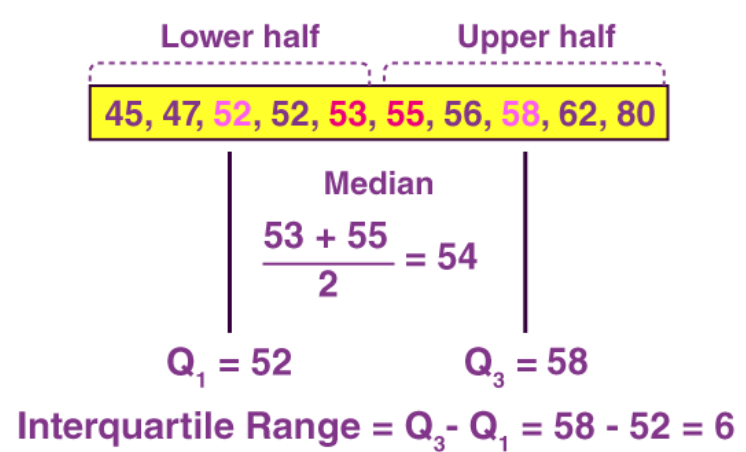

In [62]:
# Calculate IQR
numeric_cols = df.select_dtypes(include='number').columns

# Function to detect outliers
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

# Apply to each numeric column
outlier_summary = {}
for col in numeric_cols:
    outliers = detect_outliers_iqr(df[col])
    outlier_summary[col] = {
        'count': len(outliers),
        'indices': outliers.index.tolist()
    }

# Display summary
for col, info in outlier_summary.items():
    print(f"{col}: {info['count']} outliers → indices: {info['indices']}")


SepalLengthCm: 0 outliers → indices: []
SepalWidthCm: 4 outliers → indices: [15, 32, 33, 60]
PetalLengthCm: 0 outliers → indices: []
PetalWidthCm: 0 outliers → indices: []


### Box Plot

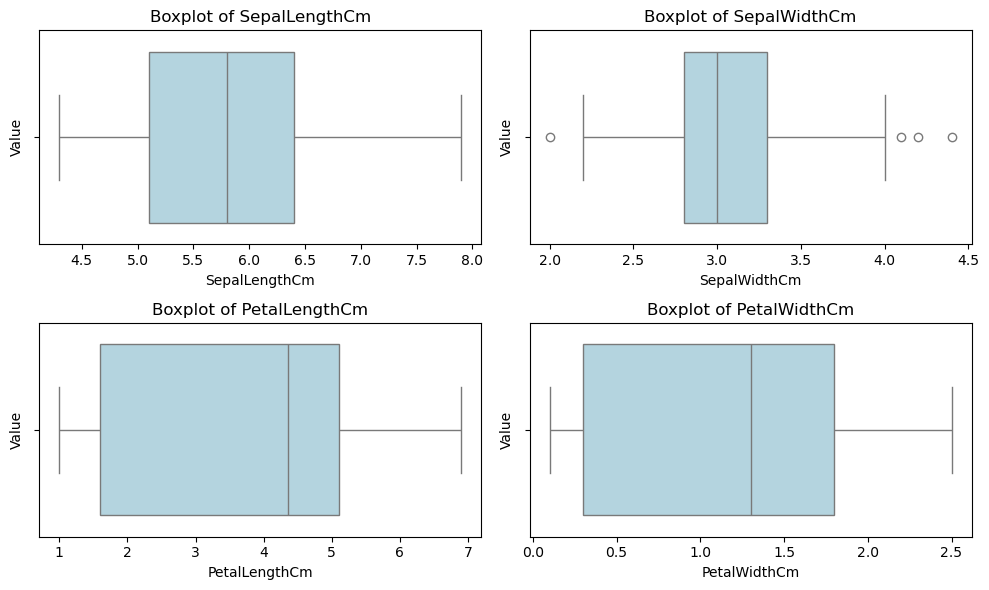

In [63]:
numeric_cols = df.select_dtypes(include='number').columns

# Create subplots: 2 rows × 2 columns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axes = axes.flatten()

# Loop through numeric columns
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()


See Sepal Widht box plot. We found 4 poits shown out of IQR range. And we calculate same this in our IQR calculations

SepalLengthCm: 0 outliers → indices: []

SepalWidthCm: 4 outliers → indices: [15, 32, 33, 60]

PetalLengthCm: 0 outliers → indices: []

PetalWidthCm: 0 outliers → indices: []

#### BoxPlot between Categorical columns and Numericals Coulms

- Box plot b/w SepalLengthCm & Species
- Box plot b/w SepalWidthCm & Species
- Box plot b/w PetalLengthCm & Species
- Box plot b/w PetalWidthCm & Species

<Axes: xlabel='SepalLengthCm', ylabel='Species'>

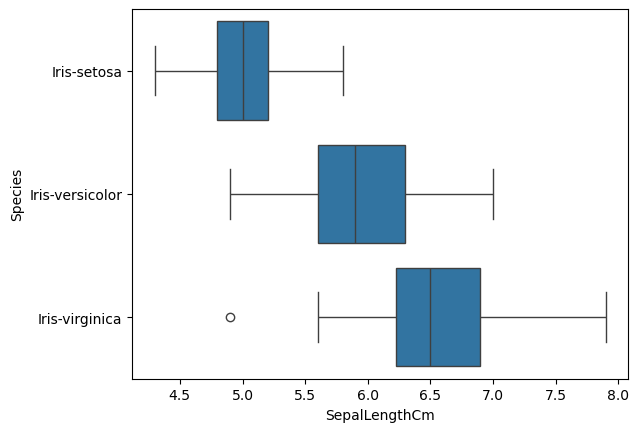

In [64]:
sns.boxplot(data=df, x="SepalLengthCm", y="Species",fill=True)

<Axes: xlabel='PetalLengthCm', ylabel='Species'>

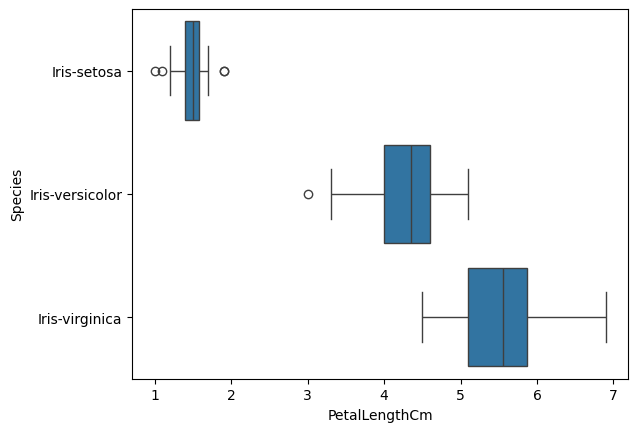

In [65]:
sns.boxplot(data=df, x="PetalLengthCm", y="Species")

<Axes: xlabel='SepalWidthCm', ylabel='Species'>

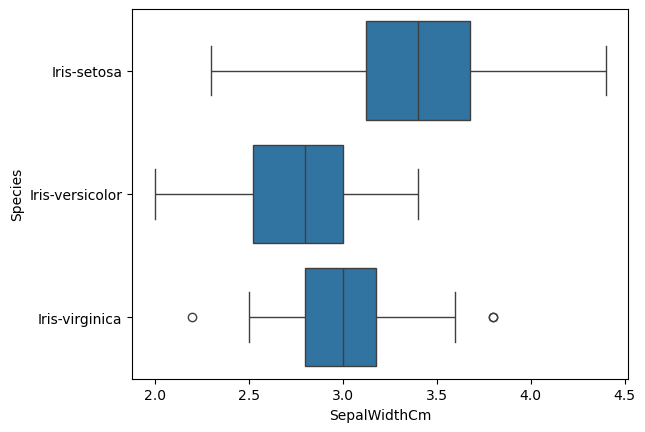

In [66]:
sns.boxplot(data=df, x="SepalWidthCm", y="Species")

<Axes: xlabel='PetalWidthCm', ylabel='Species'>

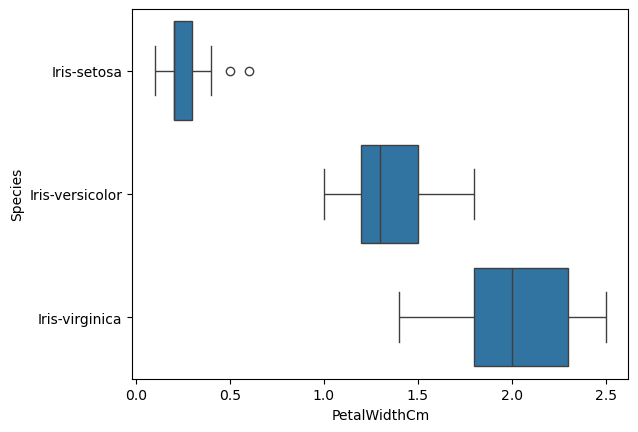

In [67]:
sns.boxplot(data=df, x="PetalWidthCm", y="Species")

### Heatmap & Check Correlations between regressor variable


Correlations lower trangular matrix:
               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm            NaN           NaN            NaN           NaN
SepalWidthCm       -0.109369           NaN            NaN           NaN
PetalLengthCm       0.871754     -0.420516            NaN           NaN
PetalWidthCm        0.817954     -0.356544       0.962757           NaN


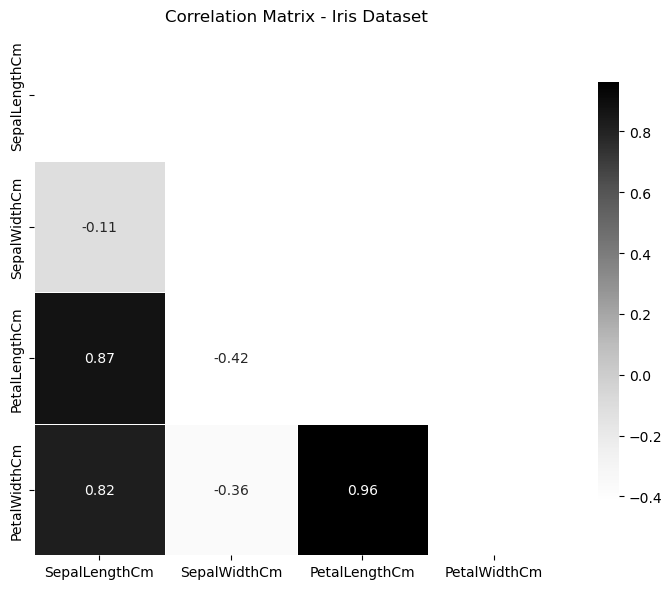

In [68]:
# Compute correlation matrix for numeric features
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
#print(f'Correlations lower trangular matrix:\n{np.round(np.tril(corr),2)}')
print(f'Correlations lower trangular matrix:\n{corr.mask(mask)}')
# Plot using gray colormap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    mask = mask,
    cmap='Greys',         # Gray-style colormap
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix - Iris Dataset')
plt.tight_layout()
plt.show()


In [69]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Mask upper triangle to avoid duplicate pairs
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_matrix_masked = corr_matrix.mask(mask)

# Find pairs with correlation > 0.9
high_corr = corr_matrix_masked.stack().reset_index()

high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_filtered = high_corr[high_corr['Correlation'] > 0.8]

print("Highly correlated column pairs (correlation > 0.8):")
print(high_corr_filtered)

Highly correlated column pairs (correlation > 0.8):
       Feature 1      Feature 2  Correlation
1  PetalLengthCm  SepalLengthCm     0.871754
3   PetalWidthCm  SepalLengthCm     0.817954
5   PetalWidthCm  PetalLengthCm     0.962757


### What we conclude ?

You can see correlations between PetalWidthCm &  PetalLengthCm  is 0.96. So we can use any one of then in our model and we found no effect on models, We will conclude this theory with hypothesis testing.    
There are more then 80% correlations exist between Petal & Sepal. So we can build our model any one of Petal or Sepal. For the same we will conclude in our models and what is effect.


### Covariance vs Correlatio
- Covariance tells you whether variables move together (positive) or in opposite directions (negative), but not how strongly.
   - Not standardized; depends on units of variables
   - Only tells direction (positive/negative)
- Correlation tells you both how strongly and in what direction variables are related, making it more interpretable and comparable across datasets.
   - Standardized between –1 and +1
   - Tells direction and strength




### Test of Multicollinearity

How VIF and Eigenvalues Are Related
1. Both derive from the correlation matrix
- VIF is computed from the inverse of the correlation matrix of predictors.
- Eigenvalues come from the eigen decomposition of the same matrix.
2. Small eigenvalues → high VIFs
- If the correlation matrix has very small eigenvalues, it means some predictors are nearly linearly dependent.
- This leads to large entries in the inverse matrix, which inflate VIF values.
3. Condition number connects them
- The condition number (ratio of largest to smallest eigenvalue) reflects how unstable the matrix inversion is.
- A high condition number → high VIFs → severe multicollinearity.

#### Eigen vector of corr matrix

In [70]:
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)
ser = pd.Series(eigenvalues,index=df.iloc[:, :-1].columns.to_list())
print(ser)
#print("Eigenvectors:\n", eigenvectors)


SepalLengthCm    2.910818
SepalWidthCm     0.921221
PetalLengthCm    0.147353
PetalWidthCm     0.020608
dtype: float64


### Eigen Value from Cov matrix

In [71]:
# Compute correlation matrix
cov_matrix = df.cov(numeric_only=True)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
ser = pd.Series(eigenvalues,index=df.iloc[:, :-1].columns.to_list())
print(ser)

SepalLengthCm    4.224841
SepalWidthCm     0.242244
PetalLengthCm    0.078524
PetalWidthCm     0.023683
dtype: float64


#### Eigen value from X'X & Conditions Number

In [76]:
fx = df.drop(['Species'], axis=1, inplace=False)
fx = fx.to_numpy()
fx = fx.T @ fx
eigenvalues, eigenvectors = np.linalg.eig(fx)
ser = pd.Series(eigenvalues,index=df.iloc[:, :-1].columns.to_list())
print(ser)
conditional_num = ser.max()/ser
conditional_num

SepalLengthCm    9206.530596
SepalWidthCm      314.103073
PetalLengthCm      12.036019
PetalWidthCm        3.530312
dtype: float64


SepalLengthCm       1.000000
SepalWidthCm       29.310540
PetalLengthCm     764.914905
PetalWidthCm     2607.852073
dtype: float64

In [73]:
# Conditions number from OLS models
X = df.drop(['Species'], axis=1, inplace=False)
y = df['Species'].map({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})
X = sm.add_constant(X)
res = sm.OLS(y,X).fit()
print("Condition Number:", res.condition_number)


Condition Number: 91.83878675061298


#### Interpretation Guide

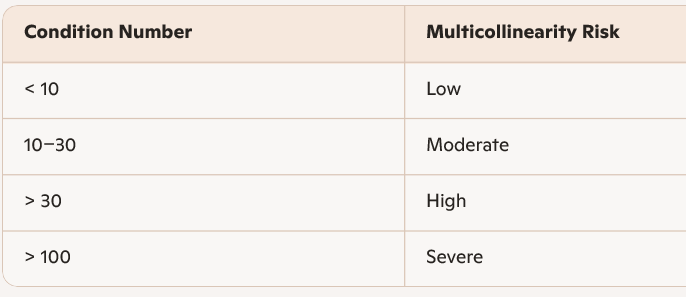

Multicollinearity Risk present High

### VIF

In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
fx =  df.iloc[:, :-1]
vif_data['feature'] = df.iloc[:, :-1].columns.to_list()
vif_data['VIF'] = [variance_inflation_factor(fx.values, i) for i in range(fx.shape[1])]
print(vif_data)


         feature         VIF
0  SepalLengthCm  264.745711
1   SepalWidthCm   97.111606
2  PetalLengthCm  173.968965
3   PetalWidthCm   55.488689


We can see VIF for SepalLengthCm is 264.745711.

This VIF calcualted between SepalLengthCm & rest of three i.e. (SepalWidthCm,PetalLengthCm,PetalWidthCm)
Similarly VIF calcualted between SepalWidthCm & rest of three i.e. (SepalLengthCm ,PetalLengthCm,PetalWidthCm) etc ...

As per VIF thumb rule

Large value of VIF's indicate multicolinearity.
- VIF > 5: Suggests moderate multicollinearity.
- VIF > 10: Indicates serious multicollinearity, which can distort regression estimates and inflate standard errors


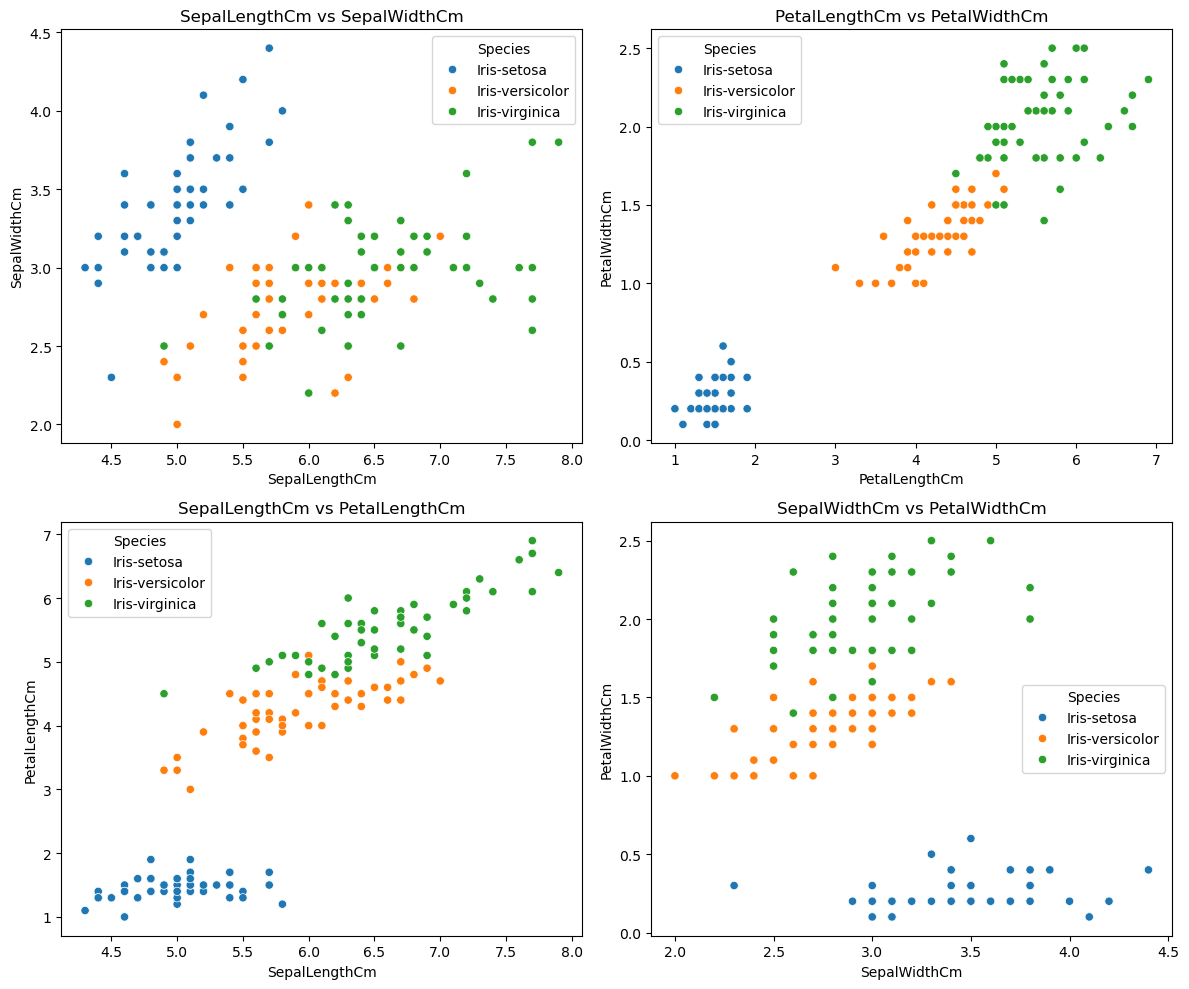

In [75]:
feature_pairs = [
    ('SepalLengthCm', 'SepalWidthCm'),
    ('PetalLengthCm', 'PetalWidthCm'),
    ('SepalLengthCm', 'PetalLengthCm'),
    ('SepalWidthCm', 'PetalWidthCm')
]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot each pair
for i, (x, y) in enumerate(feature_pairs):
    sns.scatterplot(data=df, x=x, y=y, hue='Species', ax=axes[i])
    axes[i].set_title(f'{x} vs {y}')

plt.tight_layout()
plt.show()
